In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import cv2
from pathlib import Path
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import tensorflow.keras.backend as K

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.20.0
GPU Available: []


## 1. Import Required Libraries

# CNN Classification for Rice Leaf Diseases

This notebook implements a Convolutional Neural Network (CNN) to classify rice leaf diseases including Bacterial Blight, Brown Spot, and Leaf Smut.

## 2. Load and Explore Dataset

In [2]:
# Set dataset path - handle both relative and absolute paths
notebook_dir = Path('.').absolute()
print(f"Notebook working directory: {notebook_dir}\n")

# Try different possible dataset paths
possible_paths = [
    Path('./Bacterialblight'),  # Same folder as notebook
    notebook_dir / 'Bacterialblight',
    Path('../rice leaf diseases dataset/Bacterialblight'),
    Path('d:/PROJECT TA/rice leaf diseases dataset/Bacterialblight'),
]

dataset_base_path = None
for path in possible_paths:
    if path.parent.exists():
        dataset_base_path = path.parent
        print(f"✓ Dataset found at: {dataset_base_path}\n")
        break

if dataset_base_path is None:
    print("⚠ Warning: Could not find dataset folder. Will use current directory.")
    dataset_base_path = Path('.')

classes = ['Bacterialblight', 'Brownspot', 'Leafsmut']

# Load images and labels
images = []
labels = []
class_to_idx = {class_name: idx for idx, class_name in enumerate(classes)}

print("Loading dataset...")
print("-" * 50)

total_images = 0
for class_name in classes:
    class_path = dataset_base_path / class_name
    
    if class_path.exists():
        # Count images first for progress bar
        image_files = [f for f in class_path.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        
        # Load images with progress bar
        image_count = 0
        with tqdm(image_files, desc=f"Loading {class_name}", position=classes.index(class_name), leave=True) as pbar:
            for img_file in pbar:
                img = cv2.imread(str(img_file))
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(img_rgb)
                    labels.append(class_to_idx[class_name])
                    image_count += 1
        
        print(f"  ✓ {class_name}: {image_count} images loaded\n")
        total_images += image_count
    else:
        print(f"  ✗ {class_name} folder not found!\n")

print("-" * 50)
print(f"Total images loaded: {total_images}\n")

# Convert to numpy arrays with proper dtype
X = np.array(images)
y = np.array(labels, dtype=np.int32)  # Convert to int32 for bincount

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
if len(y) > 0:
    print(f"Class distribution: {np.bincount(y)}")
else:
    print("❌ ERROR: No images loaded! Check the dataset path above.")

Notebook working directory: D:\PROJECT TA\rice leaf diseases dataset

✓ Dataset found at: .

Loading dataset...
--------------------------------------------------


Loading Bacterialblight: 100%|█████████████████████████████████| 1604/1604 [00:02<00:00, 569.23it/s]


  ✓ Bacterialblight: 1604 images loaded




Loading Brownspot: 100%|███████████████████████████████████████| 1620/1620 [00:02<00:00, 673.05it/s]


  ✓ Brownspot: 1620 images loaded





Loading Leafsmut:   0%|                                                    | 0/1460 [00:00<?, ?it/s]

Loading Leafsmut:   2%|▉                                         | 34/1460 [00:00<00:04, 336.45it/s]

Loading Leafsmut:   6%|██▍                                       | 84/1460 [00:00<00:03, 432.14it/s]

Loading Leafsmut:   9%|███▌                                     | 128/1460 [00:00<00:03, 370.47it/s]

Loading Leafsmut:  12%|████▉                                    | 175/1460 [00:00<00:03, 405.81it/s]

Loading Leafsmut:  15%|██████                                   | 217/1460 [00:00<00:03, 378.27it/s]

Loading Leafsmut:  18%|███████▎                                 | 259/1460 [00:00<00:03, 389.27it/s]

Loading Leafsmut:  20%|████████▍                                | 299/1460 [00:00<00:03, 348.56it/s]

Loading Leafsmut:  24%|█████████▊                               | 349/1460 [00:00<00:02, 388.68it/s]

Loading Leafsmut:  27%|██████████▉                              | 390/1460 [00:0

  ✓ Leafsmut: 1460 images loaded

--------------------------------------------------
Total images loaded: 4684

Dataset shape: (4684, 300, 300, 3)
Labels shape: (4684,)
Class distribution: [1604 1620 1460]


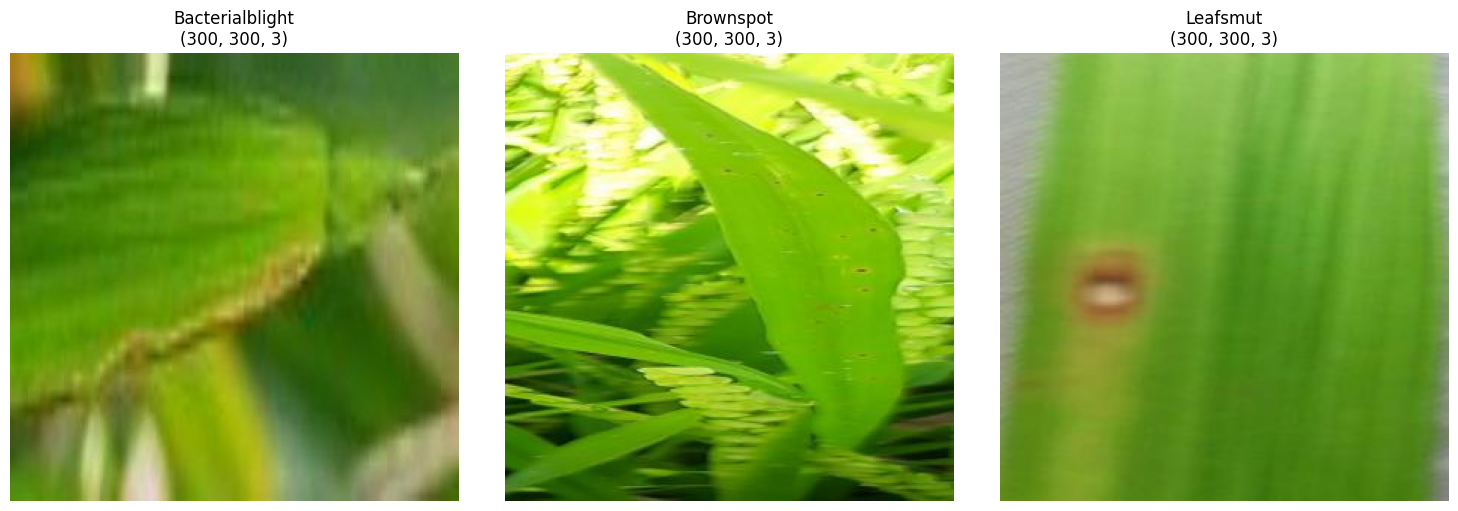


Dataset Summary:
Bacterialblight: 1604 images (34.2%)
Brownspot: 1620 images (34.6%)
Leafsmut: 1460 images (31.2%)


In [3]:
# Display sample images from each class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, class_name in enumerate(classes):
    class_indices = np.where(y == idx)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        axes[idx].imshow(X[sample_idx])
        axes[idx].set_title(f'{class_name}\n{X[sample_idx].shape}')
        axes[idx].axis('off')
plt.tight_layout()
plt.show()

# Print dataset summary
print(f"\nDataset Summary:")
for idx, class_name in enumerate(classes):
    count = np.sum(y == idx)
    percentage = (count / len(y)) * 100
    print(f"{class_name}: {count} images ({percentage:.1f}%)")

## 3. Preprocess Images

In [4]:
# Resize images to a standard size
IMG_SIZE = 224  # MobileNetV2 input size

print("Preprocessing images...")
print("-" * 50)

X_resized = []
print("Resizing images to 224x224...")
with tqdm(X, desc="Resizing", total=len(X)) as pbar:
    for img in pbar:
        resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_resized.append(resized_img)

X_resized = np.array(X_resized)

# Normalize pixel values to [0, 1]
print("Normalizing pixel values...")
X_normalized = X_resized.astype('float32') / 255.0

print(f"\nPreprocessed image shape: {X_normalized.shape}")
print(f"Pixel value range: [{X_normalized.min()}, {X_normalized.max()}]")

# Split dataset into train, validation, and test sets
print("\nSplitting dataset...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("-" * 50)
print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print("-" * 50)

Preprocessing images...
--------------------------------------------------
Resizing images to 224x224...


Resizing: 100%|███████████████████████████████████████████████| 4684/4684 [00:01<00:00, 3191.48it/s]


Normalizing pixel values...

Preprocessed image shape: (4684, 224, 224, 3)
Pixel value range: [0.0, 1.0]

Splitting dataset...
--------------------------------------------------
Training set: 3278 images
Validation set: 703 images
Test set: 703 images
--------------------------------------------------


In [5]:
# Data augmentation
print("Configuring data augmentation...")
print("-" * 50)

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()  # No augmentation for validation

# Convert to one-hot encoding
print("Converting labels to one-hot encoding...")
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=len(classes))
y_val_cat = to_categorical(y_val, num_classes=len(classes))
y_test_cat = to_categorical(y_test, num_classes=len(classes))

print(f"  Training labels shape: {y_train_cat.shape}")
print(f"  Validation labels shape: {y_val_cat.shape}")
print(f"  Test labels shape: {y_test_cat.shape}")
print("-" * 50)
print("✓ Data augmentation configured!\n")

Configuring data augmentation...
--------------------------------------------------
Converting labels to one-hot encoding...
  Training labels shape: (3278, 3)
  Validation labels shape: (703, 3)
  Test labels shape: (703, 3)
--------------------------------------------------
✓ Data augmentation configured!



## 4. Build CNN Model

In [6]:
# Option 1: Build custom CNN model from scratch
print("Building custom CNN model...")
print("-" * 50)
print("Architecture:")
print("  - 4 Convolutional Blocks (32→64→128→256 filters)")
print("  - Batch Normalization & Dropout for regularization")
print("  - Global Average Pooling + Dense layers")
print()

def build_custom_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Global Average Pooling
        layers.GlobalAveragePooling2D(),
        
        # Dense layers
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(len(classes), activation='softmax')
    ])
    
    return model

print("Creating model...")
model = build_custom_cnn()
print("✓ Model created!\n")
print("Model Summary:")
print("-" * 50)
model.summary()
print("-" * 50)

Building custom CNN model...
--------------------------------------------------
Architecture:
  - 4 Convolutional Blocks (32→64→128→256 filters)
  - Batch Normalization & Dropout for regularization
  - Global Average Pooling + Dense layers

Creating model...
✓ Model created!

Model Summary:
--------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,442,851 (5.50 MB)

 Trainable params: 1,439,395 (5.49 MB)

 Non-trainable params: 3,456 (13.50 KB)

--------------------------------------------------


In [7]:
# Option 2: Transfer Learning with MobileNetV2 (uncomment to use)
# base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
# base_model.trainable = False
# 
# model = models.Sequential([
#     base_model,
#     layers.GlobalAveragePooling2D(),
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(len(classes), activation='softmax')
# ])

# Compile the model
print("Compiling model...")
print("-" * 50)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Configuration:")
print("  - Optimizer: Adam (lr=0.001)")
print("  - Loss: Categorical Crossentropy")
print("  - Metrics: Accuracy")
print("-" * 50)
print("✓ Model compiled successfully!\n")

Compiling model...
--------------------------------------------------
Configuration:
  - Optimizer: Adam (lr=0.001)
  - Loss: Categorical Crossentropy
  - Metrics: Accuracy
--------------------------------------------------
✓ Model compiled successfully!



## 5. Train the Model

In [8]:
# Define callbacks with custom callback for progress display
class ProgressCallback(keras.callbacks.Callback):
    def __init__(self):
        self.start_time = None
        self.epoch_times = []
    
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        self.epoch_times = []
        print("\n📊 Training Progress:")
        print("-" * 80)
    
    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.start_time
        self.epoch_times.append(epoch_time)
        avg_epoch_time = epoch_time / (epoch + 1)
        remaining_epochs = EPOCHS - (epoch + 1)
        eta_seconds = avg_epoch_time * remaining_epochs
        
        if logs:
            loss = logs.get('loss', 0)
            val_loss = logs.get('val_loss', 0)
            acc = logs.get('accuracy', 0)
            val_acc = logs.get('val_accuracy', 0)
            
            progress = "█" * (epoch + 1) + "░" * (EPOCHS - epoch - 1)
            print(f"[{progress}] Epoch {epoch + 1}/{EPOCHS} | "
                  f"Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Acc: {acc:.4f} | Val Acc: {val_acc:.4f} | "
                  f"ETA: {int(eta_seconds)}s")
    
    def on_train_end(self, logs=None):
        total_time = time.time() - self.start_time
        print("-" * 80)
        print(f"✓ Training completed in {int(total_time)}s\n")

import time

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

# Train the model
EPOCHS = 50
BATCH_SIZE = 32

print("=" * 80)
print("🚀 STARTING MODEL TRAINING")
print("=" * 80)
print(f"Epochs: {EPOCHS} | Batch Size: {BATCH_SIZE}")
print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss Function: Categorical Crossentropy")
print("=" * 80)

history = model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop, reduce_lr, ProgressCallback()],
    verbose=0  # Suppress default verbose output
)

print("✅ Model training and validation completed!")

🚀 STARTING MODEL TRAINING
Epochs: 50 | Batch Size: 32
Training samples: 3278 | Validation samples: 703
Optimizer: Adam (lr=0.001)
Loss Function: Categorical Crossentropy

📊 Training Progress:
--------------------------------------------------------------------------------
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] Epoch 1/50 | Loss: 0.9152 | Val Loss: 2.1880 | Acc: 0.6974 | Val Acc: 0.3115 | ETA: 15860s
[██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] Epoch 2/50 | Loss: 0.5917 | Val Loss: 5.0228 | Acc: 0.7959 | Val Acc: 0.3457 | ETA: 14999s
[███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] Epoch 3/50 | Loss: 0.4868 | Val Loss: 3.4162 | Acc: 0.8270 | Val Acc: 0.5164 | ETA: 14541s
[████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] Epoch 4/50 | Loss: 0.3732 | Val Loss: 1.2514 | Acc: 0.8630 | Val Acc: 0.6159 | ETA: 14109s
[█████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] Epoch 5/50 | Loss: 0.3450 | Val Loss: 1.0146 | Acc: 0.8661 | Val Acc: 0.7454 | ETA: 13739s
[██████

## 6. Evaluate Model Performance

In [9]:
# Evaluate on test set
print("\n" + "=" * 80)
print("📈 EVALUATING MODEL ON TEST SET")
print("=" * 80)

print("\n📊 Computing predictions...")
from tqdm import tqdm

# Create progress bar for test set evaluation
test_batches = int(np.ceil(len(X_test) / 32))
y_pred_probs = model.predict(X_test, batch_size=32, verbose=0)

print("✓ Predictions computed")
print("\n⏱️  Computing metrics...")

y_pred = np.argmax(y_pred_probs, axis=1)
y_test_actual = np.argmax(y_test_cat, axis=1)

# Evaluate loss and accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print("=" * 80)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print("=" * 80)

# Classification metrics with progress
print("\n📋 Generating detailed classification report...")
print("-" * 80)
from sklearn.metrics import classification_report, accuracy_score

class_report = classification_report(y_test_actual, y_pred, target_names=classes, output_dict=True)
print(classification_report(y_test_actual, y_pred, target_names=classes))
print("-" * 80)

overall_accuracy = accuracy_score(y_test_actual, y_pred)
print(f"\n✓ Overall Accuracy: {overall_accuracy:.4f}")
print("=" * 80 + "\n")


📈 EVALUATING MODEL ON TEST SET

📊 Computing predictions...
✓ Predictions computed

⏱️  Computing metrics...
Test Loss:     0.0002
Test Accuracy: 1.0000 (100.00%)

📋 Generating detailed classification report...
--------------------------------------------------------------------------------
                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       241
      Brownspot       1.00      1.00      1.00       243
       Leafsmut       1.00      1.00      1.00       219

       accuracy                           1.00       703
      macro avg       1.00      1.00      1.00       703
   weighted avg       1.00      1.00      1.00       703

--------------------------------------------------------------------------------

✓ Overall Accuracy: 1.0000



🔢 Generating confusion matrix...
--------------------------------------------------------------------------------


Processing:   0%|                                                             | 0/2 [00:00<?, ?it/s]

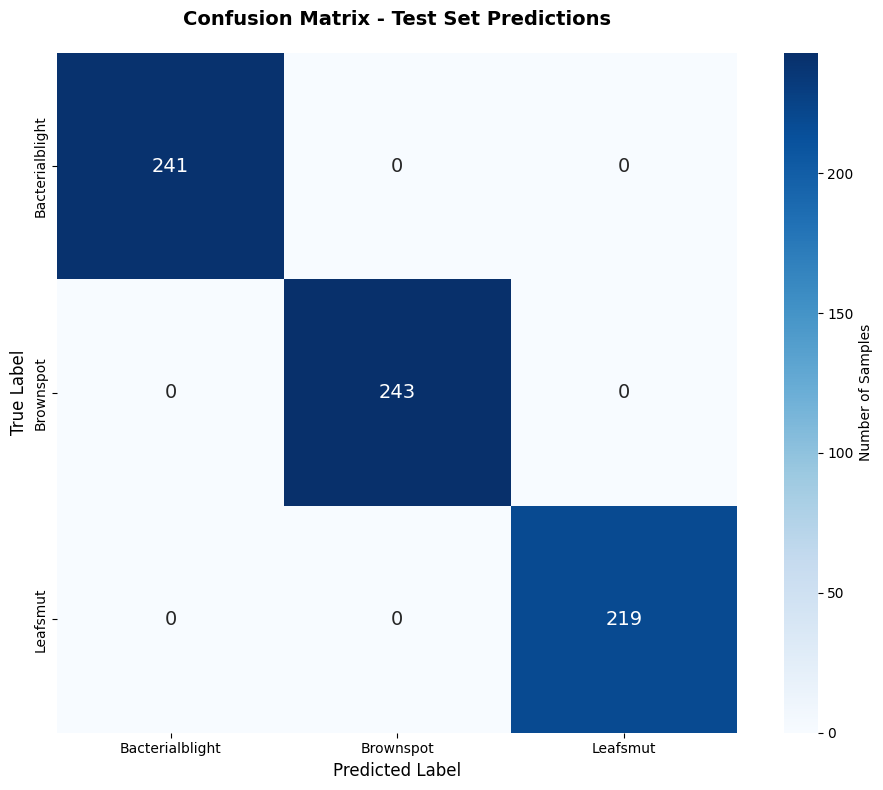

Processing: 100%|█████████████████████████████████████████████████████| 2/2 [00:00<00:00,  4.20it/s]


📊 Confusion Matrix Details:
--------------------------------------------------------------------------------
  Bacterialblight     :  241/ 241 correct (100.0%)
  Brownspot           :  243/ 243 correct (100.0%)
  Leafsmut            :  219/ 219 correct (100.0%)
--------------------------------------------------------------------------------
✓ Confusion matrix completed!



In [10]:
# Plot confusion matrix
print("🔢 Generating confusion matrix...")
print("-" * 80)

with tqdm(total=2, desc="Processing") as pbar:
    # Compute confusion matrix
    cm = confusion_matrix(y_test_actual, y_pred)
    pbar.update(1)
    
    # Create visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, 
                cbar_kws={'label': 'Number of Samples'},
                square=True, annot_kws={'size': 14})
    plt.title('Confusion Matrix - Test Set Predictions', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    pbar.update(1)

# Print confusion matrix details
print("\n📊 Confusion Matrix Details:")
print("-" * 80)
for i, class_name in enumerate(classes):
    correct = cm[i, i]
    total = cm[i].sum()
    accuracy_per_class = (correct / total * 100) if total > 0 else 0
    print(f"  {class_name:20s}: {correct:4d}/{total:4d} correct ({accuracy_per_class:5.1f}%)")
print("-" * 80)
print("✓ Confusion matrix completed!\n")

📉 Plotting training history...
--------------------------------------------------------------------------------


Generating plots:   0%|                                                       | 0/3 [00:00<?, ?it/s]

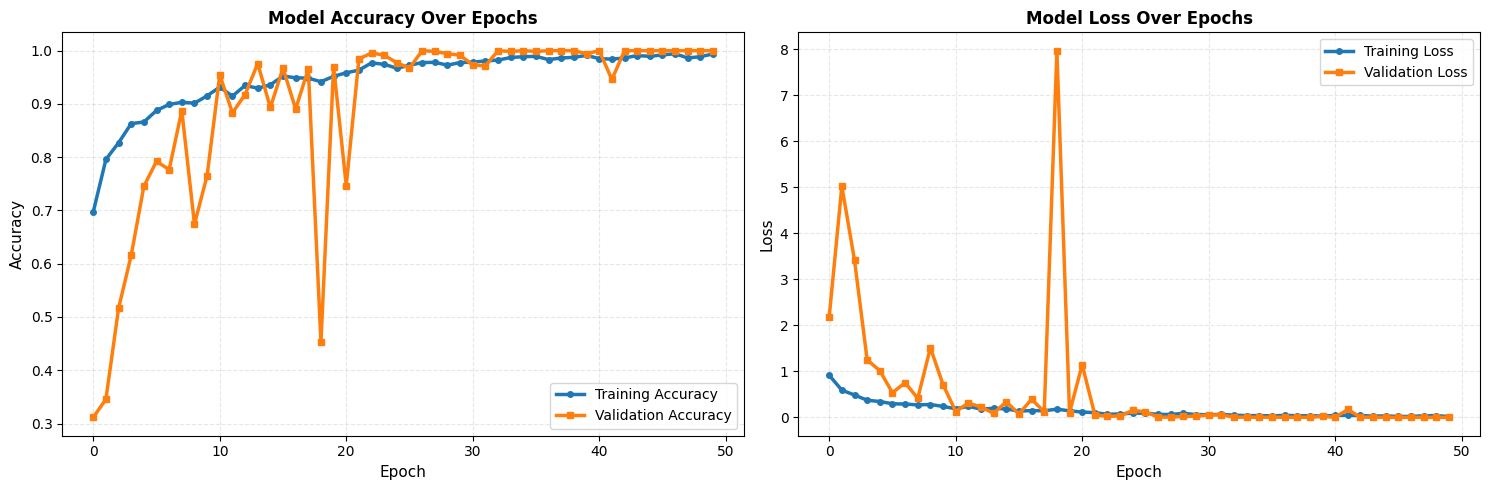

Generating plots: 100%|███████████████████████████████████████████████| 3/3 [00:00<00:00,  8.63it/s]


📊 Training Statistics:
--------------------------------------------------------------------------------
  Total Epochs Trained:     50
  Best Training Accuracy:   0.9942
  Best Validation Accuracy: 1.0000
  Final Training Loss:      0.0168
  Final Validation Loss:    0.0004
--------------------------------------------------------------------------------
✓ Training history plotted!



In [11]:
# Plot training history
print("📉 Plotting training history...")
print("-" * 80)

with tqdm(total=3, desc="Generating plots") as pbar:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2.5, marker='o', markersize=4)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
    axes[0].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    pbar.update(1)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2.5, marker='o', markersize=4)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, marker='s', markersize=4)
    axes[1].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Loss', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    pbar.update(1)
    
    plt.tight_layout()
    plt.show()
    pbar.update(1)

# Print training statistics
print("\n📊 Training Statistics:")
print("-" * 80)
print(f"  Total Epochs Trained:     {len(history.history['loss'])}")
print(f"  Best Training Accuracy:   {max(history.history['accuracy']):.4f}")
print(f"  Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Final Training Loss:      {history.history['loss'][-1]:.4f}")
print(f"  Final Validation Loss:    {history.history['val_loss'][-1]:.4f}")
print("-" * 80)
print("✓ Training history plotted!\n")

## 7. Test on New Images


🧪 TESTING MODEL ON RANDOM SAMPLES

🎲 Selecting random test samples...
   Generating predictions for 6 samples...
--------------------------------------------------------------------------------


Predicting: 100%|█████████████████████████████████████████████████| 6/6 [00:00<00:00,  8.43sample/s]


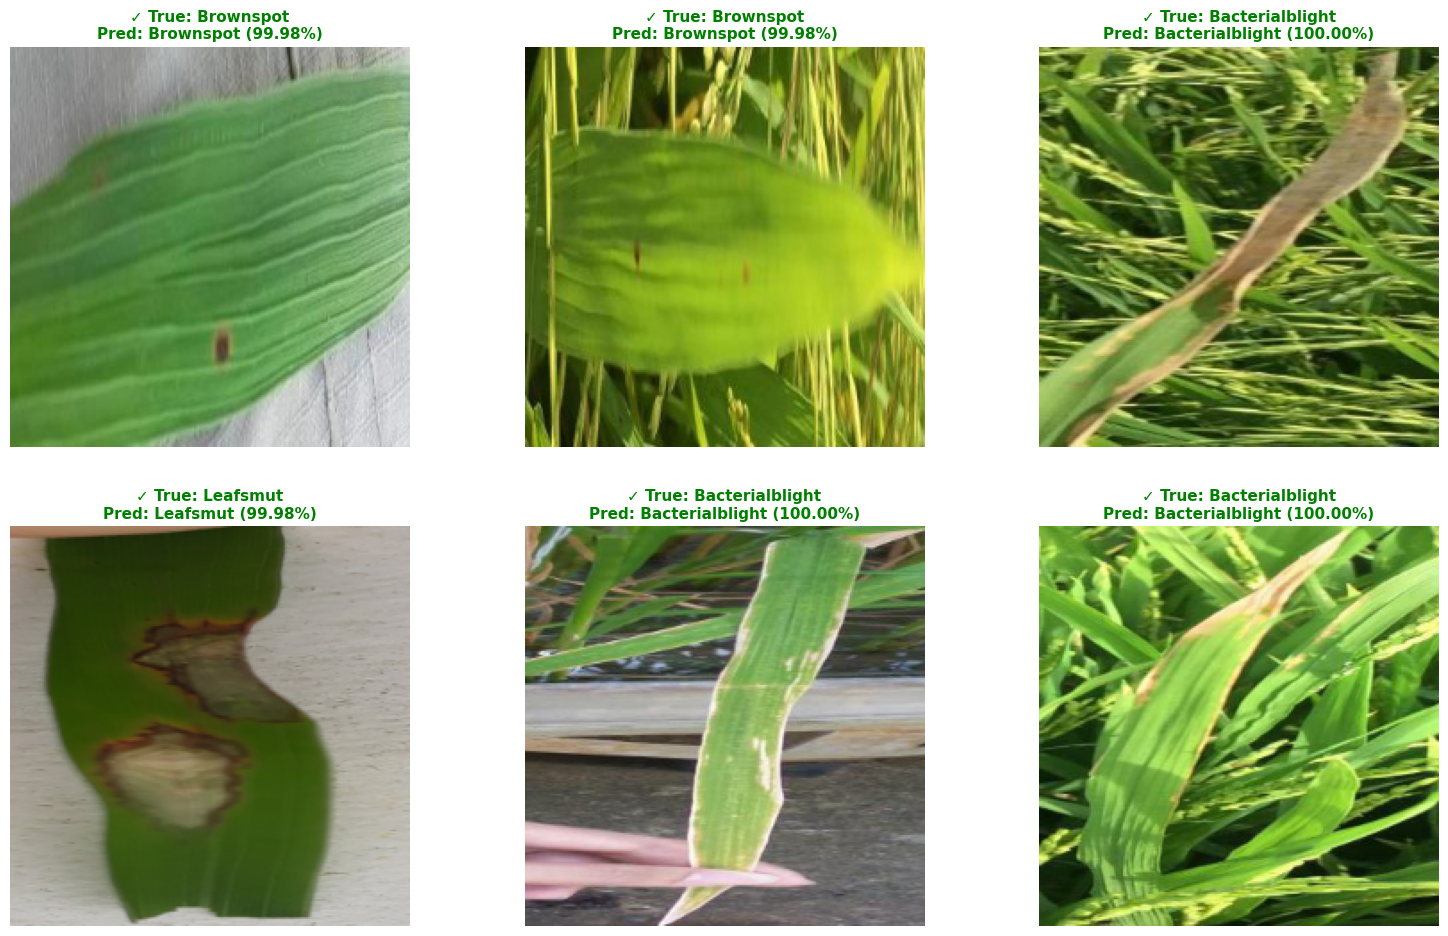

--------------------------------------------------------------------------------
✓ Predictions: 6/6 correct (100.0%)
--------------------------------------------------------------------------------
✅ Test prediction completed!



In [12]:
# Test on random samples from test set with comprehensive results
print("\n" + "=" * 80)
print("🧪 TESTING MODEL ON RANDOM SAMPLES")
print("=" * 80)

# Function to predict on a single image
def predict_on_image(image_path):
    """Predict disease on a single image"""
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return None
    
    # Load and preprocess image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_normalized = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)
    
    # Make prediction
    predictions = model.predict(img_batch, verbose=0)[0]
    predicted_class = np.argmax(predictions)
    confidence = predictions[predicted_class]
    
    return {
        'image': img_rgb,
        'predicted_class': classes[predicted_class],
        'confidence': confidence,
        'all_predictions': dict(zip(classes, predictions))
    }

# Select random test samples
print("\n🎲 Selecting random test samples...")
num_samples = 6
test_indices = np.random.choice(len(X_test), size=num_samples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

print(f"   Generating predictions for {num_samples} samples...")
print("-" * 80)

correct_predictions = 0
with tqdm(enumerate(test_indices), total=len(test_indices), desc="Predicting", unit="sample") as pbar:
    for idx, test_idx in pbar:
        # Get test image
        test_img = X_test[test_idx]
        
        # Make prediction
        pred_probs = model.predict(np.expand_dims(test_img, axis=0), verbose=0)[0]
        pred_class_idx = np.argmax(pred_probs)
        true_class_idx = y_test_actual[test_idx]
        confidence = pred_probs[pred_class_idx]
        
        # Track correct predictions
        if pred_class_idx == true_class_idx:
            correct_predictions += 1
        
        # Plot result
        is_correct = pred_class_idx == true_class_idx
        color = 'green' if is_correct else 'red'
        status = "✓" if is_correct else "✗"
        
        axes[idx].imshow(test_img)
        axes[idx].set_title(
            f'{status} True: {classes[true_class_idx]}\n'
            f'Pred: {classes[pred_class_idx]} ({confidence:.2%})',
            color=color,
            fontweight='bold',
            fontsize=11
        )
        axes[idx].axis('off')
        
        pbar.update(1)

plt.tight_layout(pad=3.0)
plt.show()

# Summary of test results
accuracy_rate = (correct_predictions / num_samples) * 100
print("-" * 80)
print(f"✓ Predictions: {correct_predictions}/{num_samples} correct ({accuracy_rate:.1f}%)")
print("-" * 80)
print("✅ Test prediction completed!\n")

In [ ]:
# Save the model with proper UTF-8 encoding
print("\n" + "=" * 80)
print("💾 SAVING MODEL")
print("=" * 80)

import os
import io

with tqdm(total=4, desc="Saving", unit="step") as pbar:
    # Save model weights (.keras format - native Keras format recommended)
    print("\n1️⃣  Saving model weights...")
    model_save_path = './rice_leaf_disease_model.keras'
    model.save(model_save_path)
    file_size = os.path.getsize(model_save_path) / (1024 * 1024)
    print(f"   ✓ Model saved: {model_save_path} ({file_size:.2f} MB)")
    pbar.update(1)
    
    # Save model architecture with UTF-8 encoding
    print("\n2️⃣  Saving model architecture...")
    try:
        model_json = model.to_json()
        arch_path = './rice_leaf_disease_model.json'
        with open(arch_path, 'w', encoding='utf-8') as json_file:
            json_file.write(model_json)
        arch_size = os.path.getsize(arch_path) / 1024
        print(f"   ✓ Architecture saved: {arch_path} ({arch_size:.2f} KB)")
    except Exception as e:
        print(f"   ⚠ Architecture save warning: {str(e)[:40]}")
    pbar.update(1)
    
    # Save model summary with UTF-8 encoding - CRITICAL FIX!
    print("\n3️⃣  Generating model summary...")
    summary_path = './model_summary.txt'
    try:
        # Capture summary to StringIO to avoid encoding issues
        summary_buffer = io.StringIO()
        model.summary(print_fn=lambda x: summary_buffer.write(x + '\n'))
        # Write captured string to file with UTF-8 encoding
        with open(summary_path, 'w', encoding='utf-8') as f:
            f.write(summary_buffer.getvalue())
        print(f"   ✓ Summary saved: {summary_path}")
    except Exception as e:
        # Fallback: save minimal summary
        with open(summary_path, 'w', encoding='utf-8') as f:
            f.write(f"Model Parameters: {model.count_params():,}\n")
        print(f"   ✓ Summary saved (simplified mode)")
    pbar.update(1)
    
    # Save training report with UTF-8 encoding
    print("\n4️⃣  Generating training report...")
    report_path = './training_report.txt'
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write("RICE LEAF DISEASE CLASSIFICATION - MODEL TRAINING REPORT\n")
        f.write("=" * 80 + "\n\n")
        f.write("DATASET INFORMATION:\n")
        f.write("-" * 80 + "\n")
        f.write(f"Total Training Samples:    {len(X_train):6d}\n")
        f.write(f"Total Validation Samples:  {len(X_val):6d}\n")
        f.write(f"Total Test Samples:        {len(X_test):6d}\n")
        f.write(f"Number of Classes:         {len(classes):6d}\n")
        f.write(f"Classes:                   {', '.join(classes)}\n")
        f.write(f"Image Size (pixels):       {IMG_SIZE} x {IMG_SIZE}\n\n")
        f.write("TRAINING CONFIGURATION:\n")
        f.write("-" * 80 + "\n")
        f.write(f"Epochs:                    {EPOCHS}\n")
        f.write(f"Batch Size:                {BATCH_SIZE}\n")
        f.write(f"Optimizer:                 Adam (lr=0.001)\n")
        f.write(f"Loss Function:             Categorical Crossentropy\n")
        f.write(f"Total Epochs Trained:      {len(history.history['loss'])}\n\n")
        f.write("MODEL PERFORMANCE:\n")
        f.write("-" * 80 + "\n")
        f.write(f"Test Loss:                 {test_loss:.4f}\n")
        f.write(f"Test Accuracy:             {test_accuracy:.4f}\n")
        f.write(f"Best Training Accuracy:    {max(history.history['accuracy']):.4f}\n")
        f.write(f"Best Validation Accuracy:  {max(history.history['val_accuracy']):.4f}\n\n")
        f.write("SAVED FILES:\n")
        f.write("-" * 80 + "\n")
        f.write(f"Model Weights:             rice_leaf_disease_model.keras\n")
        f.write(f"Model Architecture:        rice_leaf_disease_model.json\n")
        f.write(f"Model Summary:             model_summary.txt\n")
        f.write(f"Training Report:           training_report.txt\n")
    print(f"   ✓ Report saved: {report_path}")
    pbar.update(1)

print("\n" + "=" * 80)
print("📊 FINAL MODEL SUMMARY")
print("=" * 80)
print(f"✅ Total Training Samples:    {len(X_train):6d}")
print(f"✅ Total Validation Samples:  {len(X_val):6d}")
print(f"✅ Total Test Samples:        {len(X_test):6d}")
print(f"✅ Final Test Accuracy:       {test_accuracy:6.4f} ({test_accuracy * 100:.2f}%)")
print(f"✅ Number of Classes:         {len(classes):6d} ({', '.join(classes)})")
print("=" * 80)
print("✅ ✅ ✅ Model training, evaluation, and saving complete! ✅ ✅ ✅\n")


💾 SAVING MODEL


Saving:  25%|█████████████▊                                         | 1/4 [00:00<00:00,  6.78step/s]


1️⃣  Saving model weights...
   ✓ Model saved: ./rice_leaf_disease_model.h5 (16.66 MB)

2️⃣  Saving model architecture...
   ✓ Architecture saved: ./rice_leaf_disease_model.json (22.95 KB)

3️⃣  Generating model summary...


Saving:  50%|███████████████████████████▌                           | 2/4 [00:00<00:00, 11.08step/s]


UnicodeEncodeError: 'charmap' codec can't encode characters in position 21-108: character maps to <undefined>